# Variant functional consequences

This notebook provides a summary of the functional consequequences in GWAS and molQTL credible set lead variants.

Requirements:
- qualified lead variant effect

## Setup


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import plotnine as p9
from gentropy.common.session import Session
from pyspark.ml.feature import Bucketizer
from pyspark.sql import Window
from pyspark.sql import functions as f
from pyspark.sql import types as t

from manuscript_methods import OpenTargetsTheme
from manuscript_methods.datasets import LeadVariantEffect
from manuscript_methods.ve import SingleVariantEffectMethod, VariantEffect


Loading BokehJS ...

/Users/ss60/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})
qualified_replicated_lve_path = "../../../data/intermediate_files/qualified_lead_variant_effect"
REM = 8
PAV_THRESHOLD = 0.66


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/11 18:09:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/11 18:09:03 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
session.spark


## Prepare data for plotting

This section prepares datasets for plotting the functional consequences of lead variants.
This includes
- most severe consequence score from VEP transcript consequences assigned to transcript in the variant proximity
- `proteinAltering` variant (PAV) status based on consequence score filtering
- `absEstimatedBeta` from `rescaledStatistics`
- `geneId` for QTL variants and `diseaseIds` for GWAS variants (trait)


> [NOTE!] Due to the fact that lead variants - trait pairs are not unique (multiple signals can come from different cohorts/studies), we only keep the lead variants with the largest absolute effect size over disease/geneId to prevent double counting.

In [4]:
print("Number of qualified & replicated lead variant effects")
dataset = LeadVariantEffect.from_parquet(session, qualified_replicated_lve_path)
w1 = Window.partitionBy("variantId", "diseaseIds")

effect_data = (
    dataset.df.select(
        f.col("variantId"),
        f.col("geneId"),
        f.concat_ws(",", f.sort_array(f.array_distinct(f.col("diseaseIds")))).alias("diseaseIds"),
        VariantEffect(f.col("variantEffect"))
        .filter_effect_by_method(SingleVariantEffectMethod.VEP)
        .normalised_score.alias("vepScore"),
        f.col("majorLdPopulationMaf.value").alias("maf"),
        f.col("rescaledStatistics.directionOfEffect").alias("directionOfEffect"),
        f.col("rescaledStatistics.absEstimatedBeta").alias("absEstimatedBeta"),
        f.col("studyStatistics.studyType").alias("studyType"),
        f.col("leadVariantConsequence.mostSevereConsequence.transcriptConsequence.consequenceScore").alias(
            "consequenceScore"
        ),
    )
    .withColumn("consequenceScore", f.round(f.coalesce(f.col("consequenceScore"), f.col("vepScore")), 3))
    .withColumn("isProteinAltering", (f.col("consequenceScore") > PAV_THRESHOLD).cast(t.ShortType()))
    .drop("vepScore")
    # Drop rows with missing values in critical columns
    # .filter(f.col("maf").isNotNull())
    # .filter(f.col("absEstimatedBeta").isNotNull())
    # Since we have many variantId-diseaseId pairs with different effect sizes (due to multiple studies), to prevent double counting,
    # we only keep the one with the largest absolute beta
    .withColumn("hasLargestAbsBeta", f.col("absEstimatedBeta") == f.max("absEstimatedBeta").over(w1))
    .filter("hasLargestAbsBeta")
    .cache()
)

print(f"Before tranformations - {dataset.df.count():,}")
effect_data_count = effect_data.count()
print(f"After transformation - {effect_data_count:,}")


Number of qualified & replicated lead variant effects
Before tranformations - 950,517


After transformation - 235,605


In [5]:
effect_data.show()


+------------------+---------------+-------------+-------------------+-----------------+--------------------+----------------+----------------+-----------------+-----------------+
|         variantId|         geneId|   diseaseIds|                maf|directionOfEffect|    absEstimatedBeta|       studyType|consequenceScore|isProteinAltering|hasLargestAbsBeta|
+------------------+---------------+-------------+-------------------+-----------------+--------------------+----------------+----------------+-----------------+-----------------+
|  10_100152437_C_T|           NULL|MONDO_0005148|  0.473070263172968|               -1|0.021183766845275336|    gwas-disease|             0.1|                0|             true|
|  10_100267650_C_T|ENSG00000095485|             | 0.4397163362312122|                1|   1.036138723924151|            eqtl|             0.0|                0|             true|
|10_100451896_C_CTT|ENSG00000075826|             |0.20230369338452653|               -1|  1.03416698

In [6]:
effect_data.printSchema()


root
 |-- variantId: string (nullable = true)
 |-- geneId: string (nullable = true)
 |-- diseaseIds: string (nullable = false)
 |-- maf: double (nullable = true)
 |-- directionOfEffect: short (nullable = true)
 |-- absEstimatedBeta: double (nullable = true)
 |-- studyType: string (nullable = true)
 |-- consequenceScore: double (nullable = true)
 |-- isProteinAltering: short (nullable = true)
 |-- hasLargestAbsBeta: boolean (nullable = true)



### Plot the number of credible sets per each category

          studyType   count
0          cis-pqtl     465
1      gwas-disease    9760
2  gwas-measurement   48113
3              eqtl  177267


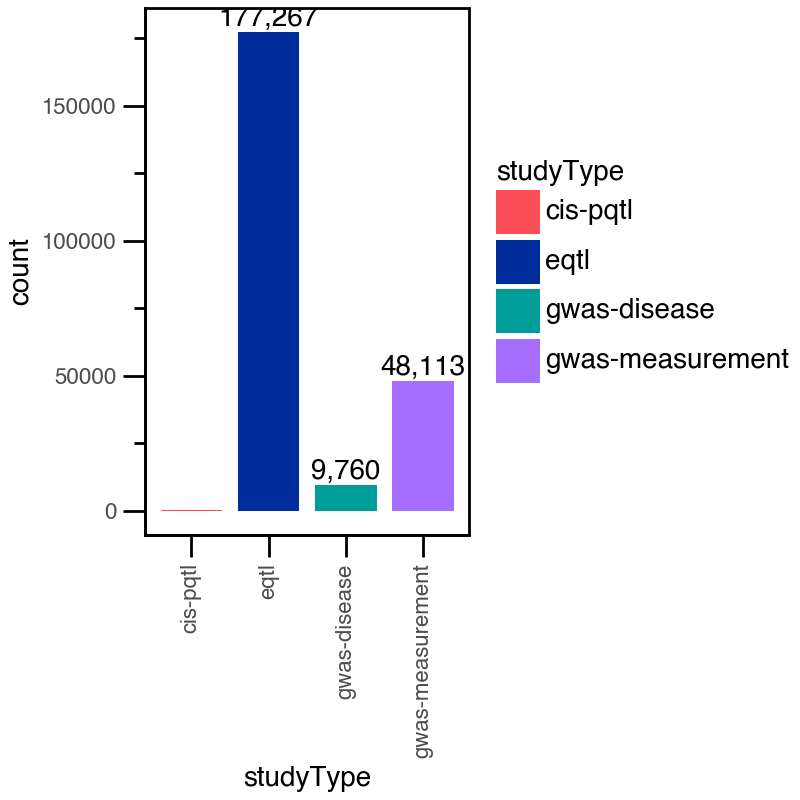

In [7]:
effect_data_batch = effect_data.groupBy("studyType").count().orderBy("count").toPandas()
print(effect_data_batch)

effect_data_batch["N"] = effect_data_batch["count"].apply(lambda x: f"{x:,}" if x > 1000 else "")

p = (
    p9.ggplot(data=effect_data_batch, mapping=p9.aes(x="studyType", y="count", fill="studyType"))
    + p9.geom_col(width=0.8)
    + OpenTargetsTheme.categorical_theme()
    + p9.theme(figure_size=(4, 4), legend_position="right")
    + p9.scale_fill_manual(values=OpenTargetsTheme.categorical_dark_colors[0:4])
    + p9.theme(
        axis_text_x=p9.element_text(size=REM, family="sans-serif", va="top", ha="center", rotation=90),
        axis_title_x=p9.element_text(size=REM + 2, family="sans-serif"),
        axis_text_y=p9.element_text(size=REM, family="sans-serif"),
        axis_title_y=p9.element_text(size=REM + 2, family="sans-serif"),
    )
    + p9.geom_text(
        p9.aes(label="N"),
        size=10,
        va="bottom",
        color="black",
        fontweight="bold",
        position=p9.position_stack(vjust=1.0),
    )
)
p


## MAF vs PAV proportion data preparation

The dataset below includes rolling mean of Protein Altering Variant Proportion over total variant count binned by Minor Allele Frequency spectrum.

In [8]:
bucketizer = Bucketizer()
# splits = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
splits = [round(v, 3) for v in np.linspace(0, 0.5, num=21)]
print(f"Using following buckets {splits}")
bucketizer.setSplits(splits)
bucketizer.setInputCol("maf")
bucketizer.setOutputCol("mafBin")
bucketizer.setHandleInvalid("error")


w1 = Window.partitionBy("studyType").orderBy("mafBin")  # .rangeBetween(-1, 1)

expr = f.when(f.lit(False), f.lit(None))
for i in range(len(splits) - 1):
    expr = expr.when(
        f.col("mafBin") == i,
        f.struct(
            f.lit(f"{splits[i]}-{splits[i + 1]}").alias("mafBinRange"),
            f.lit(splits[i]).alias("mafBinLower"),
            f.lit(splits[i + 1]).alias("mafBinUpper"),
            f.lit(np.round((splits[i] + splits[i + 1]) / 2, 3)).alias("mafBinMidpoint"),
            f.lit(i).alias("mafBinIndex"),
        ),
    )


ds = (
    bucketizer.transform(
        effect_data.select(
            "studyType",
            "absEstimatedBeta",
            "maf",
            "isProteinAltering",
        ).filter(f.col("absEstimatedBeta") < 3)
    )
    .withColumn("mafBin", f.col("mafBin").cast(t.IntegerType()))
    .withColumn(
        "absBetaOverMafBin",
        f.struct(
            f.avg(f.col("absEstimatedBeta")).over(w1).alias("avgAbsEstimatedBetaInBucket"),
            f.min(f.col("absEstimatedBeta")).over(w1).alias("minAbsEstimatedBetaInBucker"),
            f.max(f.col("absEstimatedBeta")).over(w1).alias("maxAbsEstimatedBetaInBucker"),
            f.std(f.col("absEstimatedBeta")).over(w1).alias("stdAbsEstimatedBetaInBucker"),
            f.count(f.lit(1)).over(w1).alias("nVariantsInBucket"),
        ),
    )
    .withColumn(
        "absBetaOverMafBin",
        f.struct(
            f.col("absBetaOverMafBin.*"),
            (
                f.col("absBetaOverMafBin.avgAbsEstimatedBetaInBucket")
                - (
                    (f.lit(1.96) * f.col("absBetaOverMafBin.stdAbsEstimatedBetaInBucker"))
                    / f.sqrt(f.col("absBetaOverMafBin.nVariantsInBucket"))
                )
            ).alias("avgAbsEstimatedBetaCILower"),
            (
                f.col("absBetaOverMafBin.avgAbsEstimatedBetaInBucket")
                + (
                    (f.lit(1.96) * f.col("absBetaOverMafBin.stdAbsEstimatedBetaInBucker"))
                    / f.sqrt(f.col("absBetaOverMafBin.nVariantsInBucket"))
                )
            ).alias("avgAbsEstimatedBetaCIUpper"),
        ),
    )
    .withColumn(
        "PAV",
        f.struct(
            f.sum(f.col("isProteinAltering")).over(w1).alias("nAlteringInBucket"),
            f.count(f.lit(1)).over(w1).alias("nTotalInBucket"),
            f.mean(f.col("isProteinAltering")).over(w1).alias("proportionInBucket"),
        ),
    )
    .withColumn(
        "PAV",
        f.col("PAV").withField(
            "proportionInBucketStderr",
            f.sqrt(
                (f.col("PAV.proportionInBucket") * (1 - f.col("PAV.proportionInBucket")))
                / (f.col("PAV.nTotalInBucket"))
            ),
        ),
    )
    .withColumn(
        "PAV",
        f.struct(
            f.col("PAV.*"),
            (f.col("PAV.proportionInBucket") - f.lit(1.96) * f.col("PAV.proportionInBucketStderr")).alias(
                "proportionInBucketCILower"
            ),
            (f.col("PAV.proportionInBucket") + f.lit(1.96) * f.col("PAV.proportionInBucketStderr")).alias(
                "proportionInBucketCIUpper"
            ),
        ),
    )
    .withColumn("mafBin", expr)
    .drop("absEstimatedBeta", "maf", "isProteinAltering")
    .dropDuplicates()
    .select("studyType", "PAV.*", "mafBin.*", "absBetaOverMafBin.*")
    .cache()
)
print(f"Found {ds.select('mafBinRange').distinct().count()} bins")


Using following buckets [np.float64(0.0), np.float64(0.025), np.float64(0.05), np.float64(0.075), np.float64(0.1), np.float64(0.125), np.float64(0.15), np.float64(0.175), np.float64(0.2), np.float64(0.225), np.float64(0.25), np.float64(0.275), np.float64(0.3), np.float64(0.325), np.float64(0.35), np.float64(0.375), np.float64(0.4), np.float64(0.425), np.float64(0.45), np.float64(0.475), np.float64(0.5)]


Found 20 bins


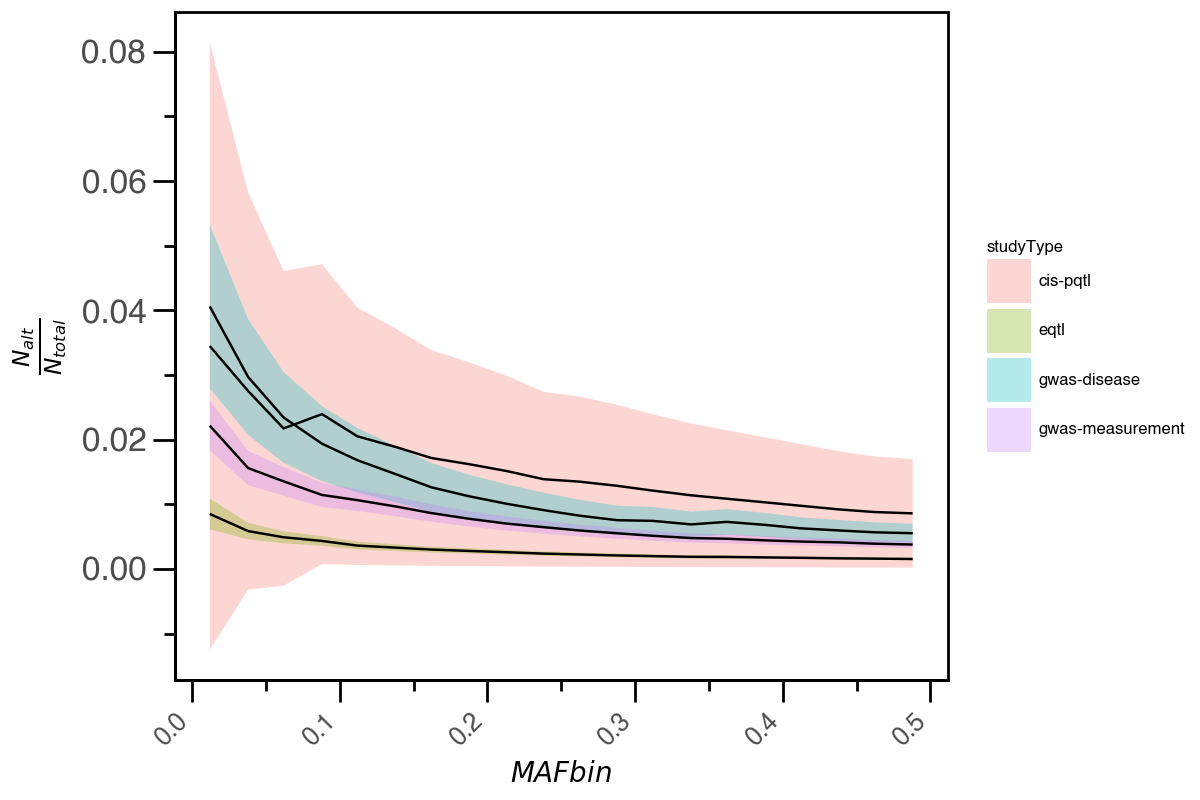

In [9]:
p2 = ds.select(
    "proportionInBucket",
    "mafBinMidpoint",
    "studyType",
    "proportionInBucketCILower",
    "proportionInBucketCIUpper",
).toPandas() >> p9.ggplot(
    mapping=p9.aes(
        x="mafBinMidpoint",
        y="proportionInBucket",
        fill="studyType",
        ymin="proportionInBucketCILower",
        ymax="proportionInBucketCIUpper",
    ),
) + p9.geom_ribbon(alpha=0.3, color=None) + p9.labs(
    # title="Proportion of lead variant effects in replicated credible sets",
    x=r"$MAF bin$",
    y=r"$\frac{N_{alt}}{N_{total}}$",
) + p9.geom_line() + OpenTargetsTheme.categorical_theme(REM=6) + p9.theme(
    figure_size=(6, 4), legend_position="right"
) + p9.theme(axis_title_x=p9.element_text(size=10))
p2


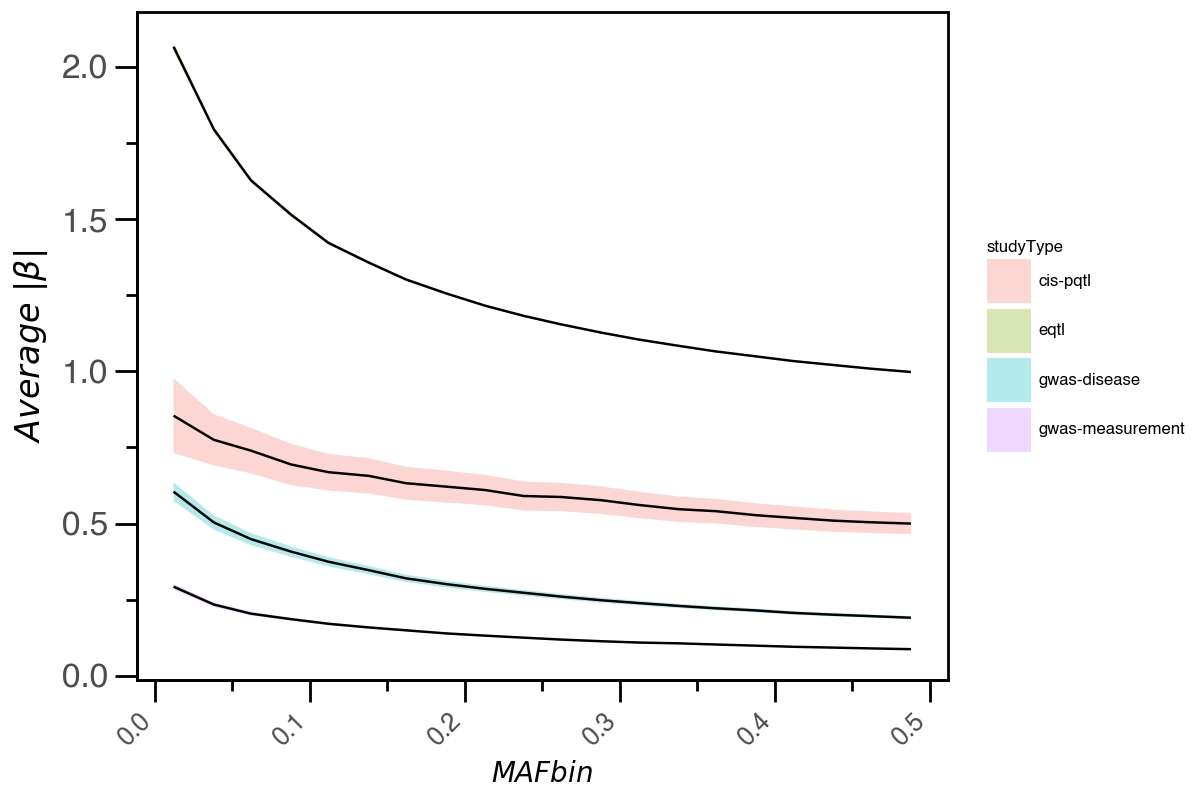

In [10]:
p3 = (
    ds.select(
        "avgAbsEstimatedBetaInBucket",
        "mafBinMidpoint",
        "studyType",
        "avgAbsEstimatedBetaCILower",
        "avgAbsEstimatedBetaCIUpper",
    ).toPandas()
    >> p9.ggplot(
        mapping=p9.aes(
            x="mafBinMidpoint",
            y="avgAbsEstimatedBetaInBucket",
            fill="studyType",
            ymin="avgAbsEstimatedBetaCILower",
            ymax="avgAbsEstimatedBetaCIUpper",
        ),
    )
    + p9.geom_ribbon(alpha=0.3, color=None)
    + p9.labs(  # title="Average absolute beta in MAF bins",
        x=r"$MAF bin$",
        y=r"$Average\ |\beta|$",
    )
    + OpenTargetsTheme.categorical_theme(REM=6)
    + p9.theme(figure_size=(6, 4), legend_position="right")
    + p9.theme(axis_title_x=p9.element_text(size=10))
    + p9.geom_line()
)
p3


## Plots v1


/var/folders/l7/4z91w2tj4wscfcpfjjy3s0mr0000gq/T/ipykernel_83898/2484020832.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



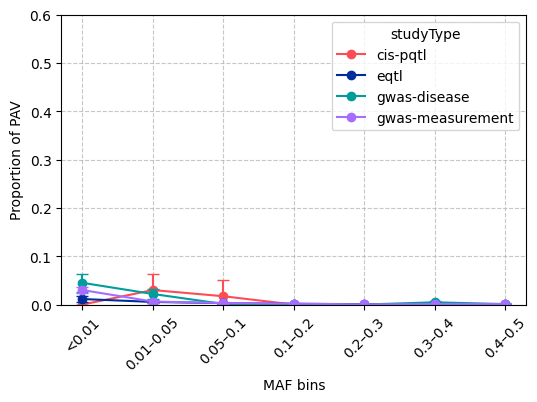

25/12/11 19:24:21 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 918934 ms exceeds timeout 120000 ms
25/12/11 19:24:21 WARN SparkContext: Killing executors is not supported by current scheduler.
25/12/11 19:24:25 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [ ]:
# df = maf_vep_dataset_alt
df = effect_data.toPandas()
from matplotlib import pyplot as plt
# Определяем интервалы

bins = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
labels = ["<0.01", "0.01–0.05", "0.05–0.1", "0.1–0.2", "0.2–0.3", "0.3–0.4", "0.4–0.5"]

df["maf_bin"] = pd.cut(df["maf"], bins=bins, labels=labels, include_lowest=True)

# Группируем по studyType + maf_bin
bin_stats = df.groupby(["studyType", "maf_bin"])["isProteinAltering"].agg(["mean", "count", "sum"]).reset_index()
bin_stats.rename(columns={"mean": "p", "count": "n", "sum": "n_pav"}, inplace=True)

# SE и доверительные интервалы
bin_stats["SE"] = np.sqrt(bin_stats["p"] * (1 - bin_stats["p"]) / bin_stats["n"])
bin_stats["CI_lower"] = (bin_stats["p"] - 1.96 * bin_stats["SE"]).clip(0, 1)
bin_stats["CI_upper"] = (bin_stats["p"] + 1.96 * bin_stats["SE"]).clip(0, 1)

colors = {"cis-pqtl": "#fa4d56", "eqtl": "#002d9c", "gwas-disease": "#009d9a", "gwas-measurement": "#a56eff"}

plt.figure(figsize=(6, 5))
plt.subplots_adjust(bottom=0.3)
for study, sub in bin_stats.groupby("studyType"):
    color = colors.get(study, "black")  # fallback to black if studyType not in dict
    # Line + markers
    plt.plot(sub["maf_bin"], sub["p"], marker="o", linestyle="-", label=study, color=color)
    # CI as error bars
    plt.errorbar(sub["maf_bin"], sub["p"], yerr=1.96 * sub["SE"], fmt="none", capsize=4, color=color)


plt.xlabel("MAF bins")
plt.ylabel("Proportion of PAV")
# plt.title("PAV proportion by MAF bins (with 95% CI) per studyType")
plt.xticks(rotation=45)
plt.ylim(0, 0.6)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="studyType")
plt.show()
